In [256]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

In [258]:
df = pd.read_csv("Studio Ghibli Films.csv")

In [260]:
df

,Name,Year,Director,Screenplay,Budget,Revenue,Genre 1,Genre 2,Genre 3,Duration
0,When Marnie Was There\n (2014),2014,Hiromasa Yonebayashi,Joan G. Robinson,$10500000,$35012681,Animation,Drama,NaN,1h 43m
1,The Tale of The Princess Kaguya\n (2013),2013,Isao Takahata,Riko Sakaguchi,$49300000,$24751400,Animation,Drama,Fantasy,2h 17m
2,The Wind Rises\n (2013),2013,Hayao Miyazaki,Tatsuo Hori,$30000000.00,$136865366,Drama,Animation,Romance,2h 6m
3,From Up on Poppy Hill\n (2011),2011,Goro Miyazaki,Hayao Miyazaki,$22000000.00,$61485364,Animation,Drama,NaN,1h 31m
4,The Secret World of Arrietty\n (2010),2010,Hiromasa Yonebayashi,Mary Norton,$23000000.00,$149689984,Fantasy,Animation,Family,1h 34m
5,Ponyo\n (2008),2008,Hayao Miyazaki,NaN,$34000000,$205906593,Animation,Fantasy,Family,1h 40m
6,Ocean Waves\n (1994),1994,Tomomi Mochizuki,Saeko Himuro,NaN,$87738,Animation,Drama,Romance,1h 12m
7,Tales from Earthsea\n (2006),2006,Goro Miyazaki,Ursula K. Le Guin,$22000000.00,$68673762,Animation,Fantasy,Adventure,1h 55m
8,Only Yesterday\n (1991),1991,Isao Takahata,NaN,NaN,$608562,Animation,Drama,Romance,1h 59m
9,Spirited Away\n (2001),2001,Hayao Miyazaki,NaN,$19000000.00,$358380478,Animation,Family,Fantasy,2h 5m


In [261]:
df.columns

Index(['Name', 'Year', 'Director', 'Screenplay', 'Budget', 'Revenue',
       'Genre 1', 'Genre 2', 'Genre 3', 'Duration'],
      dtype='object')

In [262]:
df.info

<bound method DataFrame.info of                                               Name  Year  \
0             When Marnie Was There\n       (2014)  2014   
1   The Tale of The Princess Kaguya\n       (2013)  2013   
2                    The Wind Rises\n       (2013)  2013   
3             From Up on Poppy Hill\n       (2011)  2011   
4      The Secret World of Arrietty\n       (2010)  2010   
5                             Ponyo\n       (2008)  2008   
6                       Ocean Waves\n       (1994)  1994   
7               Tales from Earthsea\n       (2006)  2006   
8                    Only Yesterday\n       (1991)  1991   
9                     Spirited Away\n       (2001)  2001   
10         My Neighbors the Yamadas\n       (1999)  1999   
11             Whisper of the Heart\n       (1995)  1995   
12           Grave of the Fireflies\n       (1988)  1988   
13               My Neighbor Totoro\n       (1988)  1988   
14                Princess Mononoke\n       (1997)  1997   
15      

In [263]:
# Remove any non-numeric characters and convert to float
df['Budget'] = df['Budget'].replace('[\\$,]', '', regex=True).astype(float)
df['Revenue'] = df['Revenue'].replace('[\\$,]', '', regex=True).astype(float)

# Filter out invalid data again
df_clean = df[['Name', 'Director' , 'Budget', 'Revenue']].copy()
df_clean = df_clean.dropna()
df_clean = df_clean[(df_clean['Budget'] > 0) & (df_clean['Revenue'] > 0)]

# Calculate Profit and ROI
df_clean['Profit'] = df_clean['Revenue'] - df_clean['Budget']
df_clean['ROI'] = df_clean['Revenue'] / df_clean['Budget']

# Sort by ROI to get top 10
df_top_roi = df_clean.sort_values(by='ROI', ascending=False).head(10)

df_top_roi


,Name,Director,Budget,Revenue,Profit,ROI
9,Spirited Away\n (2001),Hayao Miyazaki,19000000.0,358380478.0,339380478.0,18.862130
15,Howl's Moving Castle\n (2004),Hayao Miyazaki,24000000.0,241145634.0,217145634.0,10.047735
21,Nausicaä of the Valley of the Wind,Hayao Miyazaki,1000000.0,9010711.0,8010711.0,9.010711
13,My Neighbor Totoro\n (1988),Hayao Miyazaki,3700000.0,30327833.0,26627833.0,8.196712
14,Princess Mononoke\n (1997),Hayao Miyazaki,23500000.0,170333762.0,146833762.0,7.248245
4,The Secret World of Arrietty\n (2010),Hiromasa Yonebayashi,23000000.0,149689984.0,126689984.0,6.508260
5,Ponyo\n (2008),Hayao Miyazaki,34000000.0,205906593.0,171906593.0,6.056076
2,The Wind Rises\n (2013),Hayao Miyazaki,30000000.0,136865366.0,106865366.0,4.562179
22,The Boy and the Heron,Hayao Miyazaki,50000000.0,172766713.0,122766713.0,3.455334
0,When Marnie Was There\n (2014),Hiromasa Yonebayashi,10500000.0,35012681.0,24512681.0,3.334541


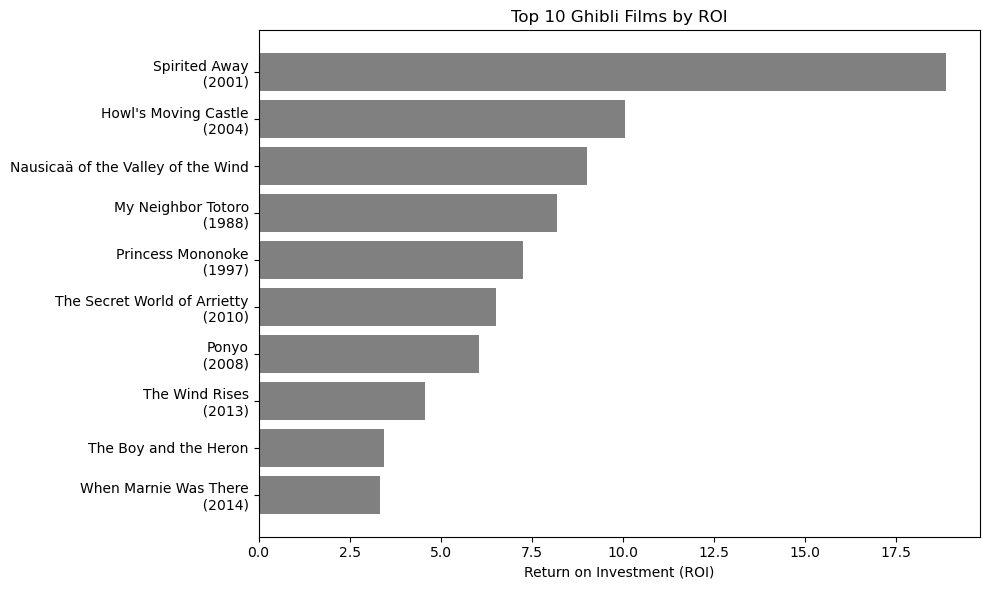

In [264]:
# Sort values (so barh goes from lowest to highest)
df_top_roi_sorted = df_top_roi.sort_values(by='ROI')

# Plot
plt.figure(figsize=(10, 6))
plt.barh(df_top_roi_sorted['Name'], df_top_roi_sorted['ROI'], color='grey')
plt.xlabel('Return on Investment (ROI)')
plt.title('Top 10 Ghibli Films by ROI')
plt.tight_layout()
plt.show()


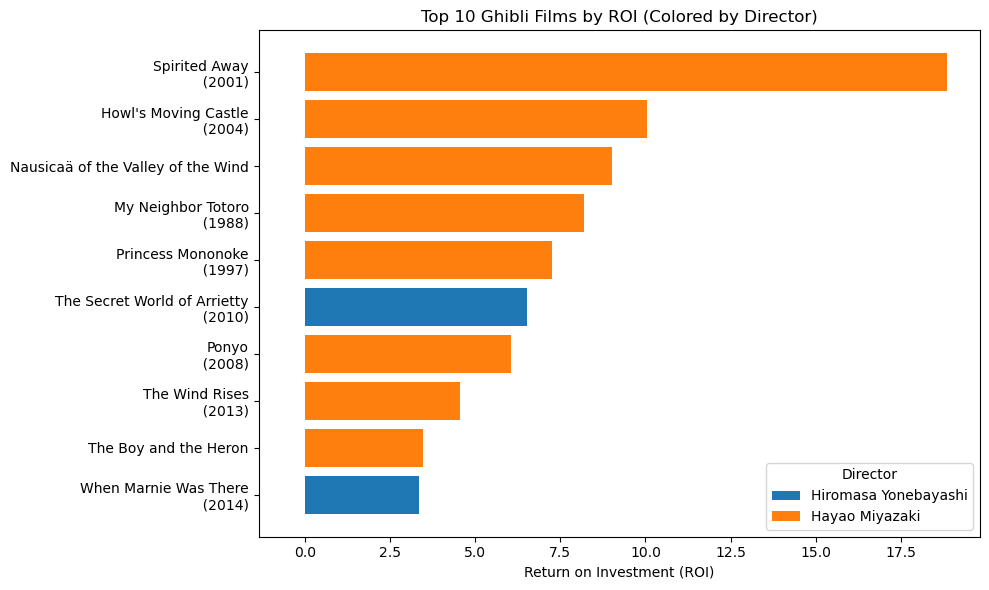

In [265]:
# Assign a unique color to each director
directors = df_top_roi_sorted['Director'].unique()
color_map = {name: color for name, color in zip(directors, plt.cm.tab10.colors)}

# Get colors for each bar based on director
bar_colors = df_top_roi_sorted['Director'].map(color_map)

# Plot with color
plt.figure(figsize=(10, 6))
plt.barh(df_top_roi_sorted['Name'], df_top_roi_sorted['ROI'], color=bar_colors)

# Add legend 
for name, color in color_map.items():
    plt.bar(0, 0, color=color, label=name)
plt.legend(title='Director')

# Labels
plt.xlabel('Return on Investment (ROI)')
plt.title('Top 10 Ghibli Films by ROI (Colored by Director)')
plt.tight_layout()
plt.show()

In [266]:
df_plot = df[['Name', 'Year', 'Director', 'Budget', 'Revenue']].copy()
df_plot['Budget'] = df_plot['Budget'].replace(r'[\$,]', '', regex=True).astype(float)
df_plot['Revenue'] = df_plot['Revenue'].replace(r'[\$,]', '', regex=True).astype(float)
df_plot = df_plot.dropna()

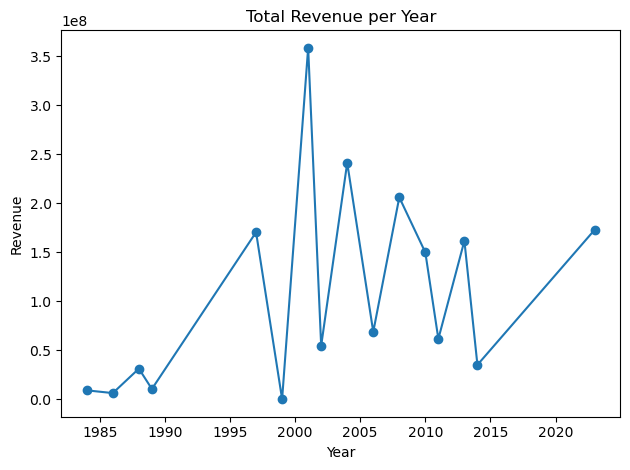

In [267]:
# Group by year and sum revenue
revenue_per_year = df_plot.groupby('Year')['Revenue'].sum().sort_index()

plt.plot(revenue_per_year.index, revenue_per_year.values, marker='o')
plt.title("Total Revenue per Year")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


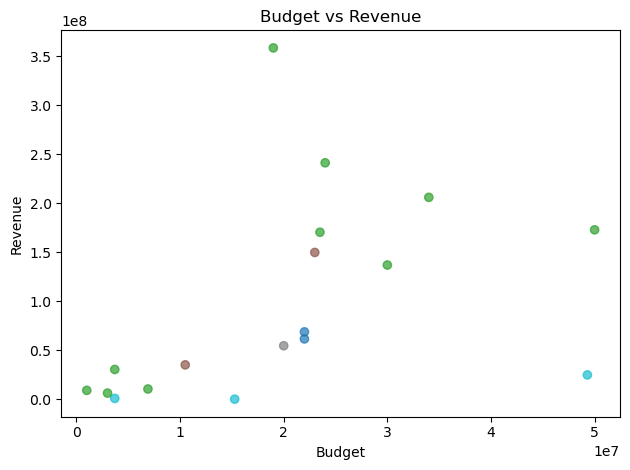

In [268]:
directors = df_plot['Director'].astype('category')
colors = directors.cat.codes  # Convert each director to a numeric color

plt.scatter(df_plot['Budget'], df_plot['Revenue'], c=colors, cmap='tab10', alpha=0.7)
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


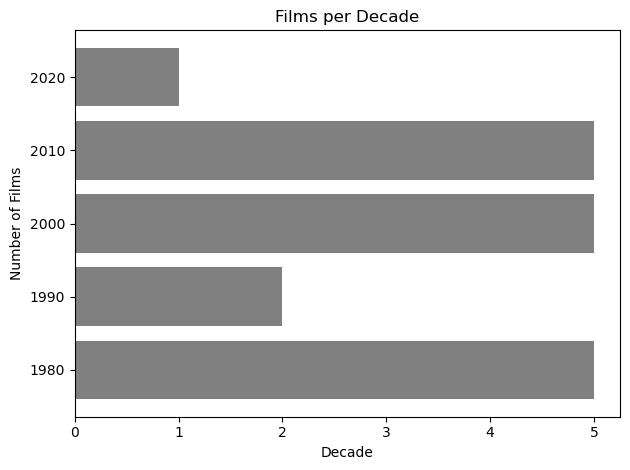

In [269]:
df_plot['Decade'] = (df_plot['Year'] // 10) * 10
films_per_decade = df_plot['Decade'].value_counts().sort_index()

plt.barh(films_per_decade.index.astype(str), films_per_decade.values, color='grey')
plt.title("Films per Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Films")
plt.tight_layout()
plt.show()


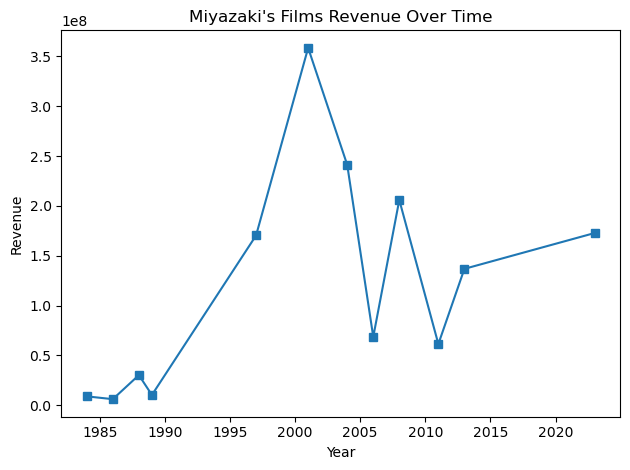

In [270]:
miyazaki = df_plot[df_plot['Director'].str.contains("Miyazaki")].sort_values('Year')

plt.plot(miyazaki['Year'], miyazaki['Revenue'], marker='s', linestyle='-')
plt.title("Miyazaki's Films Revenue Over Time")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


In [271]:
all_genres = pd.concat([df['Genre 1'], df['Genre 2'], df['Genre 3']])
genre_counts = all_genres.value_counts().dropna()

In [272]:
df['Revenue'] = df['Revenue'].replace(r'[\$,]', '', regex=True).astype(float)
avg_revenue_by_genre = df.groupby('Genre 1')['Revenue'].mean().dropna().sort_values(ascending=False)

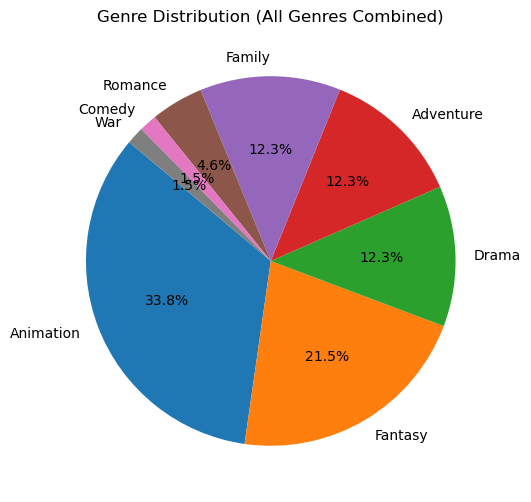

In [273]:
plt.figure(figsize=(14, 6))
# Pie Chart
plt.subplot(1, 2, 1)
genre_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title("Genre Distribution (All Genres Combined)")
plt.ylabel('')
plt.show()

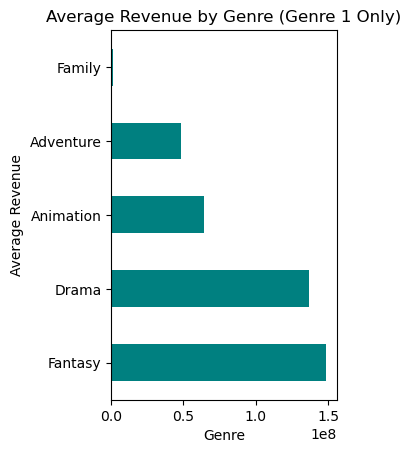

In [275]:
# Bar Chart
plt.subplot(1, 2, 2)
avg_revenue_by_genre.plot(kind='barh', color='teal')
plt.title("Average Revenue by Genre (Genre 1 Only)")
plt.xlabel("Genre")
plt.ylabel("Average Revenue")
plt.show()

In [276]:
# Clean up newline characters and spaces
df['Name'] = df['Name'].str.strip().str.replace(r'\n', '', regex=True)
df = df.dropna(subset=['Name', 'Year', 'Director', 'Screenplay', 'Genre 1', 'Duration'])

In [277]:
#Little Fun Quiz Here
def ghibli_quiz(df, rounds=5):
    score = 0
    for _ in range(rounds):
        row = df.sample().iloc[0]
        name = row['Name']
        options = [
            f"What year was '{name}' released?",
            f"Who directed '{name}'?",
            f"Who wrote the screenplay for '{name}'?",
            f"What is the duration of '{name}' (in minutes)?",
            f"What is the primary genre of '{name}'?"
        ]
        question_type = random.choice(options)
        
        # Ask question
        if "year" in question_type:
            answer = input(question_type + " ")
            correct = str(row['Year'])
        elif "directed" in question_type:
            answer = input(question_type + " ")
            correct = row['Director']
        elif "screenplay" in question_type:
            answer = input(question_type + " ")
            correct = row['Screenplay']
        elif "duration" in question_type:
            answer = input(question_type + " ")
            correct = str(int(row['Duration_Minutes']))

        elif "genre" in question_type:
            answer = input(question_type + " ")
            correct = row['Genre 1']
        else:
            continue
        
        if answer.strip().lower() == str(correct).strip().lower():
            print("Correct!\n")
            score += 1
        else:
            print(f"Nope! The correct answer was: {correct}\n")
    
    print(f"Quiz complete! You scored {score}/{rounds}.")


In [ ]:
ghibli_quiz(df)


Summary
In this analysis of the Studio Ghibli film dataset, we explored financial trends, genre popularity, and key director impacts across the studio’s filmography. One of the most profitable films by ROI was Spirited Away, with a return nearly 19 times its budget. Director Hayao Miyazaki consistently produced high-revenue films over the years, showing his strong impact on Ghibli’s success.

We also found that genres like Fantasy and Adventure are the most commonly used, while certain genres, such as Romance, tend to have lower representation. Average revenue analysis shows that Fantasy and Drama genres (as primary genres) typically bring in the highest earnings.

Future Use of This Dataset
This dataset can be used for:

Trend forecasting: Understanding which types of stories perform best for future film planning

Director or genre-based investment analysis

Fan engagement tools, like quiz games or genre-based recommendations

Data visualization practice for students learning Python and storytelling through data

As more Studio Ghibli films are released, this dataset could be updated to continue tracking long-term trends in genre, profitability, and artistic leadership.

